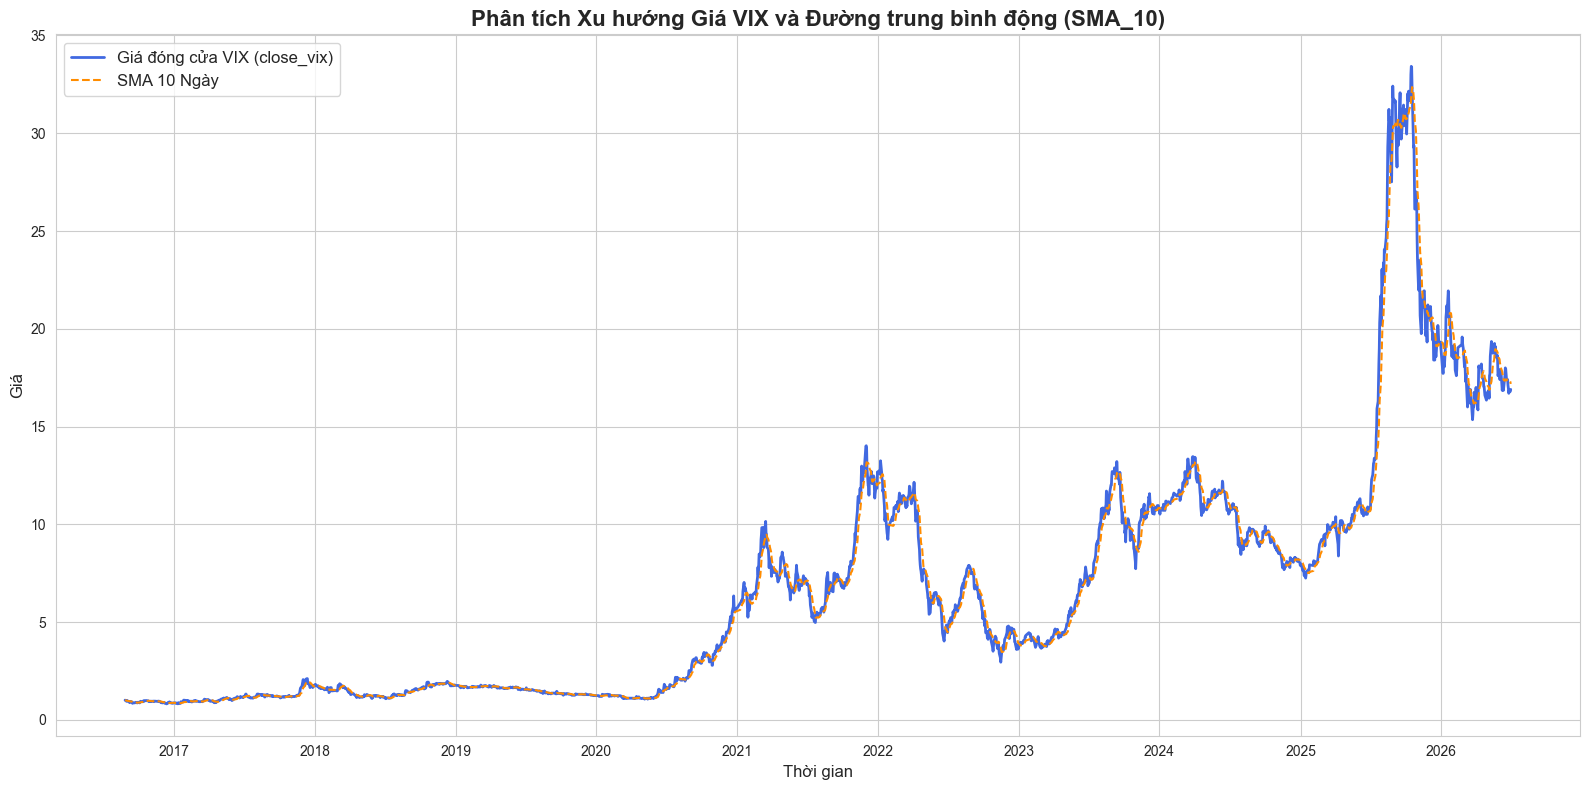

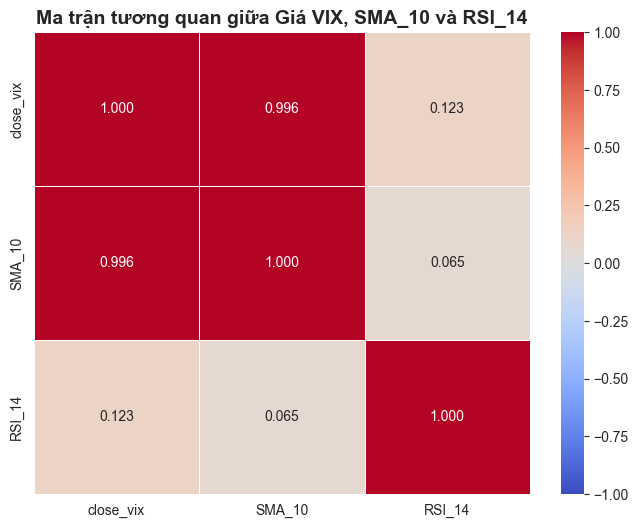

Độ tương quan với giá close_vix:
close_vix    1.000000
SMA_10       0.995692
RSI_14       0.123462
Name: close_vix, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu và set index bằng cột 'time'
df = pd.read_csv('vix_features_1D_updated.csv')
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)

# 2. Vẽ biểu đồ xu hướng
sns.set_style("whitegrid")
plt.figure(figsize=(16, 8))
plt.plot(df.index, df['close_vix'], label='Giá đóng cửa VIX (close_vix)', color='royalblue', linewidth=2)

if 'SMA_10' in df.columns:
    plt.plot(df.index, df['SMA_10'], label='SMA 10 Ngày', color='darkorange', linestyle='--')

plt.title('Phân tích Xu hướng Giá VIX và Đường trung bình động (SMA_10)', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Tính toán và vẽ ma trận tương quan
features = ['close_vix', 'SMA_10', 'RSI_14'] 
corr_matrix = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa Giá VIX, SMA_10 và RSI_14', fontsize=14, fontweight='bold')
plt.show()

print("Độ tương quan với giá close_vix:")
print(corr_matrix['close_vix'].sort_values(ascending=False))

📊 KẾT QUẢ ĐÁNH GIÁ BASELINE MODEL
Mô hình sử dụng: Linear Regression
Biến độc lập (Features): SMA_10, RSI_14
RMSE trên tập Test: 0.8997


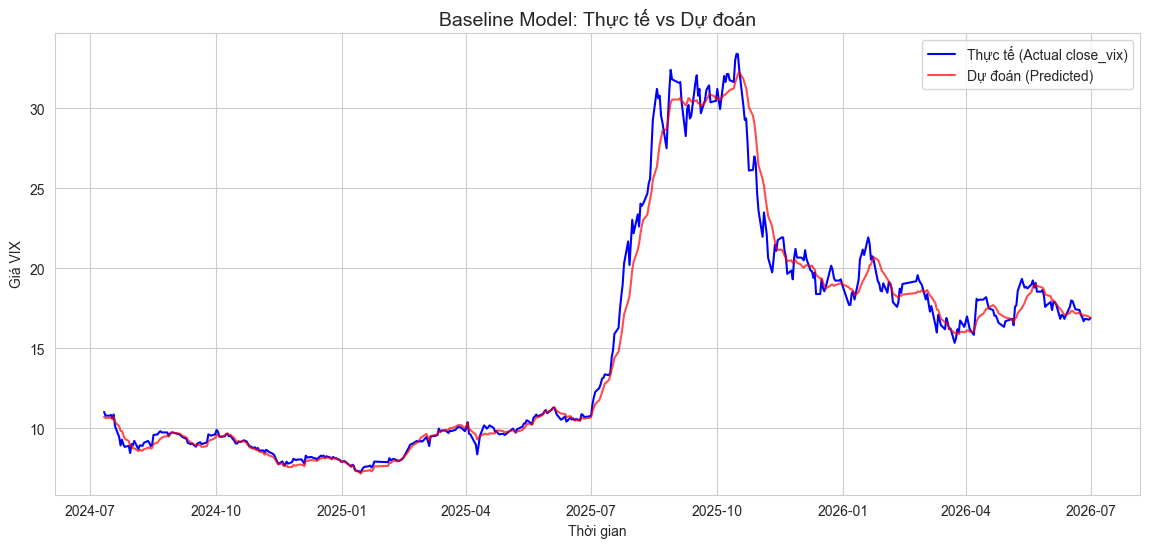

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Lấy đúng các cột cần thiết và xử lý NaN
df_model = df[['close_vix', 'SMA_10', 'RSI_14']].dropna()

# 2. Tách biến độc lập (Features) và biến phụ thuộc (Target)
X = df_model[['SMA_10', 'RSI_14']]
y = df_model['close_vix'] 

# 3. Chia tập Train/Test theo tỷ lệ 80/20 (Không xáo trộn dữ liệu Time-series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Khởi tạo và huấn luyện mô hình Linear Regression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 5. Dự đoán trên tập Test
y_pred = baseline_model.predict(X_test)

# 6. Đánh giá mô hình bằng RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("="*40)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ BASELINE MODEL")
print("="*40)
print(f"Mô hình sử dụng: Linear Regression")
print(f"Biến độc lập (Features): SMA_10, RSI_14")
print(f"RMSE trên tập Test: {rmse:.4f}")
print("="*40)

# Trực quan hóa giá trị thực tế vs giá trị dự đoán
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Thực tế (Actual close_vix)', color='blue')
plt.plot(y_test.index, y_pred, label='Dự đoán (Predicted)', color='red', alpha=0.7)
plt.title('Baseline Model: Thực tế vs Dự đoán', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Giá VIX')
plt.legend()
plt.show()

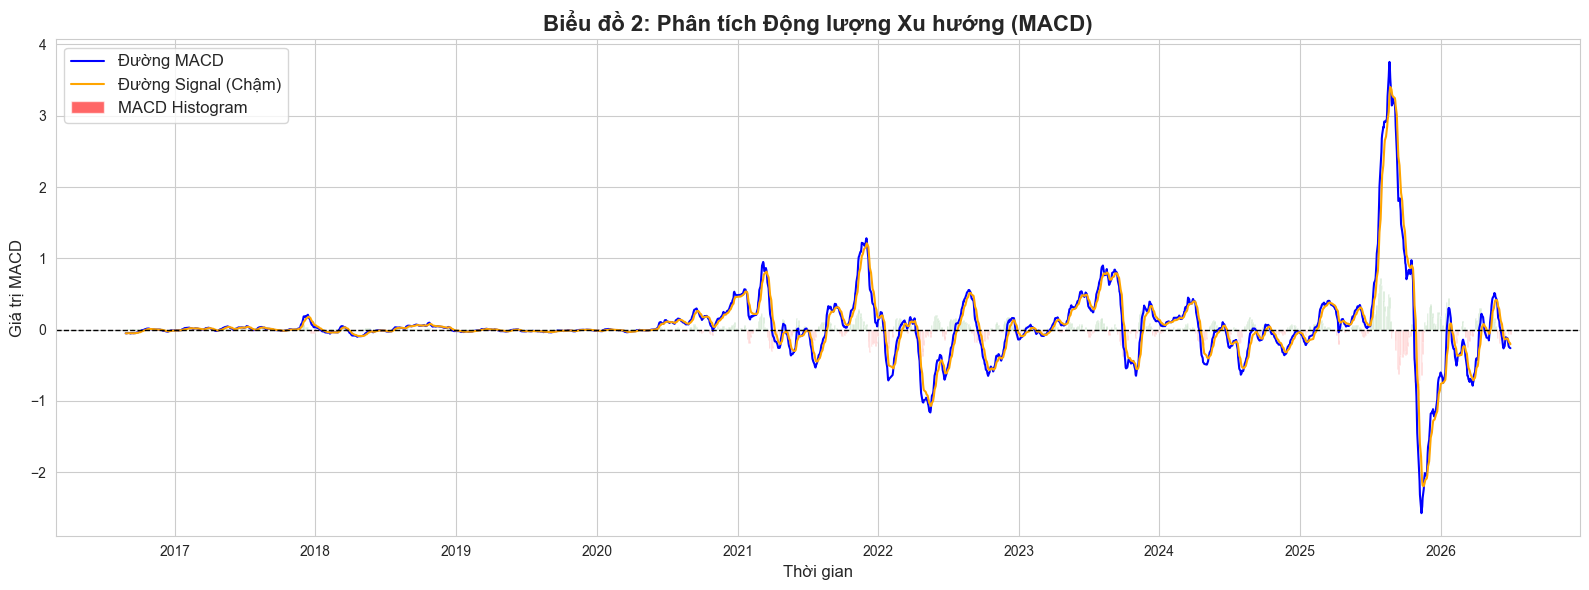

In [6]:
plt.figure(figsize=(16, 6))

# Vẽ đường MACD và đường Signal
plt.plot(df.index, df['MACD'], label='Đường MACD', color='blue', linewidth=1.5)
plt.plot(df.index, df['MACD_Signal'], label='Đường Signal (Chậm)', color='orange', linewidth=1.5)

# Tính toán MACD Histogram (Khoảng cách giữa MACD và Signal)
macd_hist = df['MACD'] - df['MACD_Signal']

# Vẽ Histogram: Màu xanh nếu MACD > Signal (Động lượng Tăng), Màu đỏ nếu ngược lại (Động lượng Giảm)
colors = ['green' if val >= 0 else 'red' for val in macd_hist]
plt.bar(df.index, macd_hist, label='MACD Histogram', color=colors, alpha=0.6, width=1.5)

# Vẽ đường zero làm gốc
plt.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title('Biểu đồ 2: Phân tích Động lượng Xu hướng (MACD)', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá trị MACD', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()